<a href="https://colab.research.google.com/github/zry3fr/undergrad_ml_assignments/blob/main/COMPLETE_05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. We use them to model complex, non-linear data that standard linear models cannot handle. Real world outcomes aren't always continuous like what linear regression implies. For example, logistic regression uses an activation function to map predictions into a valid range (such as 0 to 1 for probabilities). This lets us model things like probabilities or categories, which a standard linear model can’t do properly. Overall, they are more flexibileand produce outputs that make sense for classification purposes.
2. They are effective loss functions because they directly measure how far the predicted probabilities are from the correct outcomes. Cross entropy evaluates the certainty of a prediction. It encourages the model to output percise probabilities rather than just a binary of 0 or 1. Additionally, they penalize confident but wrong predictions. For example, if the correct outcome is 1 and the predicted probability is close to 0, the loss approaches infinity, forcing the model to make significant changes. This penalty helps the model improve overall.
3. True, logistic regression is a linear model. It is linear based on the coefficients and inputs. Specifically, it forms a linear combination of the features. However, the output is transformed through a non-linear function, which makes the final prediction non-linear. Therefore, it is linear in its structure but non-linear in its output.
4. False, logistic regression is specifically designed for classification. Logistic regression maps categorical outcomes into a linear function of inputs to predict probabilities.
We can turn those probabilities into class labels. For example, using a threshold like 0.5.
5. No, in logistic regression, coefficients represent the change in the log-odds of the outcome for a 1 unit change in the feature. This means the effect on the actual probability is non-linear and depends on the current value.
6. False, although logistic regression has a non-linear output, the relationship between features and the log-odds is still linear. Because it is a linear model, logistic regression cannot model complex, non-linear relationships in raw data. Feature engineering allows transformation from non-linear relationships into linear ones by creating interaction terms, polynomial features, or applying transformations. Therefore, if the accurate relationship is more complex, we still need feature engineering to capture it.
7. False. Logistic regression is better for classification problems, especially when predicting probabilities. However, ordinary least squares is better for continuous outcomes. Each model has its functions for different types of problems. Therefore, one is not always better than the other.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`



In [1]:
! git clone https://github.com/zry3fr/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 33 (delta 10), reused 4 (delta 4), pack-reused 19 (from 1)
Receiving objects: 100% (33/33), 42.65 KiB | 727.00 KiB/s, done.
Resolving deltas: 100% (11/11), done.
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 33 (delta 10), reused 4 (delta 4), pack-reused 19 (from 1)
Receiving objects: 100% (33/33), 42.65 KiB | 727.00 KiB/s, done.
Resolving deltas: 100% (11/11), done.
Download complete
Extracting data files...
Download complete
Extracting data files...
Data extracted
Data extracted


1.

In [2]:
import pandas as pd
import numpy as np

In [4]:
drop = pd.read_csv("/content/data.csv", sep=';')
drop.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [5]:
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]

drop = drop[cols]

In [6]:
drop.isnull().sum()

,0
Debtor,0
Tuition fees up to date,0
Scholarship holder,0
Age at enrollment,0
Curricular units 1st sem (approved),0
Target,0


In [7]:
drop = drop.dropna()

I checked for missing values and removed rows with missing data using dropna(). Since the dataset is large, this does not significantly affect results.

In [8]:
drop["Dropout"] = drop["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

I created a binary target by turning the 3 category variable into a binary classification problem.

2.

In [9]:
from sklearn.linear_model import LogisticRegression

In [10]:
X = drop[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]

y = drop["Dropout"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

In [11]:
coeffs = pd.Series(model.coef_[0], index=X.columns)
coeffs

,0
Debtor,0.530625
Tuition fees up to date,-2.556542
Scholarship holder,-1.227442
Age at enrollment,0.049925


Being a debtor and older age at enrollment are associated with a higher probability of dropping out, because their coefficients are positive. In contrast, being up to date on tuition fees and being a scholarship holder are associated with a lower probability of dropping out, because their coefficients are negative. Specifically, being up to date on tuition clearly reduces dropout risk by a large margin. This suggests that financial stability plays an important role in whether students stay enrolled.

3.

In [12]:
drop["dropout_prob"] = model.predict_proba(X)[:, 1]

In [13]:
import matplotlib.pyplot as plt

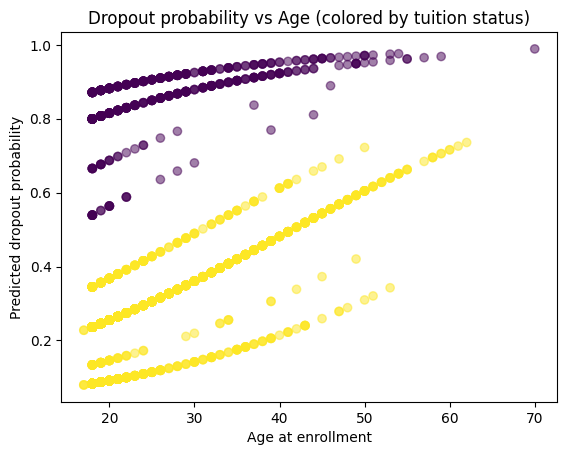

In [14]:
plt.scatter(
    drop["Age at enrollment"],
    drop["dropout_prob"],
    c=drop["Tuition fees up to date"],
    alpha=0.5
)

plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.title("Dropout probability vs Age (colored by tuition status)")
plt.show()

Being up to date on tuition reduces dropout probability for older ages the most. At higher ages, the gap between students who are up to date on tuition and those who are not becomes larger, meaning tuition status matters more.

In [15]:
drop.groupby("Tuition fees up to date")["dropout_prob"].mean()

,dropout_prob
Tuition fees up to date,
0,0.860675
1,0.248090


In [16]:
means = drop.groupby("Tuition fees up to date")["dropout_prob"].mean()

mean_diff = means[0] - means[1]
mean_diff

np.float64(0.6125849339840048)

On average, being up to date on tuition lowers the predicted probability of dropout by about 61.3%. This is a very large difference, showing that tuition status is one of the strongest predictors of dropout risk. Students who are not up to date on tuition are much more likely to drop out compared to those who are current on their payments.

4.

In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [18]:
y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print(cm)
print("Accuracy:", acc)

[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


The accuracy of the model is about 76.2%.

5.

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
lin_model = LinearRegression()
lin_model.fit(X, y)

drop["lin_prob"] = lin_model.predict(X)

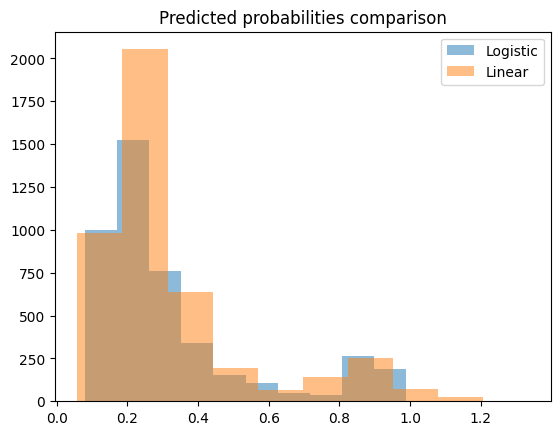

In [21]:
plt.hist(drop["dropout_prob"], alpha=0.5, label="Logistic")
plt.hist(drop["lin_prob"], alpha=0.5, label="Linear")
plt.legend()
plt.title("Predicted probabilities comparison")
plt.show()

The logistic regression model produces predicted probabilities that are confined between 0 and 1 and form a more realistic distribution. In contrast, the linear model produces a wider range of predictions, with some values being below 0 and above 1 (which are not valid probabilities). While both models capture similar overall patterns, the logistic regression model performs better because it provides accurately constrained and preciser probability estimates.

6.

The students most at risk of dropping out are students that have outstanding debt, are not up to date on tuition, do not have scholarships, older, and have fewer approved courses (low performance). Some interventions that could help include financial aid, academic advising, and peer mentorship programs to help students manage their finances and academics.

7.

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
X_multi = drop[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]

y_multi = drop["Target"]

multi_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi_model.fit(X_multi, y_multi)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [24]:
y_pred_multi = multi_model.predict(X_multi)

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_multi, y_pred_multi))

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


In [25]:
multi_model.classes_

array(['Dropout', 'Enrolled', 'Graduate'], dtype=object)

The multinomial logistic regression model shows uneven predictive performance across the Target categories. While it performs well for Dropout and Graduate, it completely fails to predict Enrolled. This is shown by the zero counts in the predicted Enrolled column of the confusion matrix. This indicates that the model assigns no observations to the Enrolled category. For Dropout, the model correctly classifies 1054 cases but misclassifies 367 as Graduate. For Enrolled, all correct cases are misclassified (280 as Dropout and 514 as Graduate). For Graduate, the model performs best, correctly classifying 2063 cases with relatively few misclassifications.


In [26]:
probs = multi_model.predict_proba(X_multi)
print(probs[:5])

[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


The hard classification does not predict every class as shown by the confusion matrix where the model never predicts the Enrolled category. However, the predicted probabilities do include all three classes for every observation. This means that while the model assigns a probability to Dropout, Enrolled, and Graduate in each case, Enrolled is never the most likely class. Therefore, it never becomes the final predicted label even if it is still considered in the probability distribution.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead



1.

In [28]:
cirr = pd.read_csv("/content/data/cirrhosis.csv")
cirr.head(10)

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
5,6,2503,D,Placebo,24201,F,N,Y,N,N,0.8,248.0,3.98,50.0,944.0,93.00,63.0,NaN,11.0,3.0
6,7,1832,C,Placebo,20284,F,N,Y,N,N,1.0,322.0,4.09,52.0,824.0,60.45,213.0,204.0,9.7,3.0
7,8,2466,D,Placebo,19379,F,N,N,N,N,0.3,280.0,4.00,52.0,4651.2,28.38,189.0,373.0,11.0,3.0
8,9,2400,D,D-penicillamine,15526,F,N,N,Y,N,3.2,562.0,3.08,79.0,2276.0,144.15,88.0,251.0,11.0,2.0
9,10,51,D,Placebo,25772,F,Y,N,Y,Y,12.6,200.0,2.74,140.0,918.0,147.25,143.0,302.0,11.5,4.0


In [38]:
cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
cirr = cirr[cols]
cirr

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL
...,...,...,...,...,...
307,0.4,N,D-penicillamine,2.0,C
308,0.4,N,Placebo,2.0,C
309,1.7,N,D-penicillamine,2.0,C
310,2.0,N,D-penicillamine,2.0,C


In [39]:
cirr.isna().sum()

,0
Bilirubin,0
Edema,0
Drug,0
Stage,0
Status,0


In [40]:
cirr = cirr.dropna()
cirr

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL
...,...,...,...,...,...
307,0.4,N,D-penicillamine,2.0,C
308,0.4,N,Placebo,2.0,C
309,1.7,N,D-penicillamine,2.0,C
310,2.0,N,D-penicillamine,2.0,C


I checked for missing values and removed rows with missing data using dropna().

In [41]:
cirr["Survival"] = cirr["Status"].apply(lambda x: 1 if x in ["C", "CL"] else 0)

In [42]:
cirr = pd.get_dummies(cirr, columns=["Edema", "Drug"], drop_first=True)

I created the survival target that converts categorical variables into numberic form using dummy variables.

2.

In [44]:
X = cirr.drop(columns=["Status", "Survival", "Stage"])
y = cirr["Survival"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

In [45]:
coeffs = pd.Series(model.coef_[0], index=X.columns)
coeffs

,0
Bilirubin,-0.351424
Edema_S,-0.450677
Edema_Y,-1.611049
Drug_Placebo,0.231225


The results suggest that the drug does not improve survival probability. The coefficient for Drug_Placebo is positive (0.231) which indicates that patients in the placebo group have slightly higher odds of survival compared to those receiving the drug (D-penicillamine).

Bilirubin shows a negative coefficient (-0.351) which means that higher bilirubin levels are associated with lower survival probability and vise versa.

Edema also shows a strong relationship with survival. Compared to patients with no Edema, those with Edema_S have lower survival probability and those with Edema_Y have an even more lower survival odds.

3.

In [46]:
cirr["survival_prob"] = model.predict_proba(X)[:, 1]

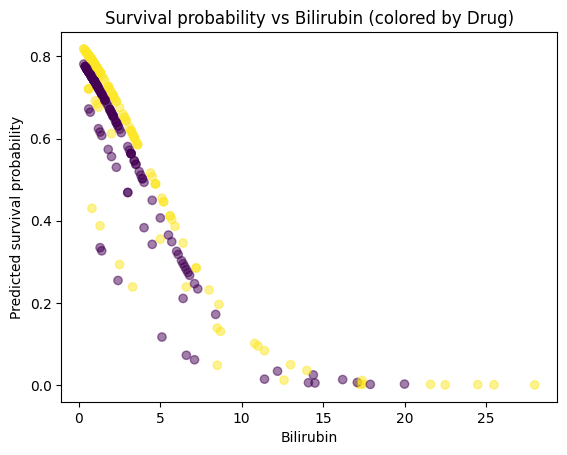

In [53]:
plt.scatter(
    cirr["Bilirubin"],
    cirr["survival_prob"],
    c=cirr["Drug_Placebo"],
    alpha=0.5
)

plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.title("Survival probability vs Bilirubin (colored by Drug)")
plt.show()

Based on the graph, it seems that for lower values of Bilirubin the drug increases patient survival rate. For example, values below 10 of Bilirubin have higher predicted survival probability.


In [55]:
cirr.groupby("Drug_Placebo")["survival_prob"].mean()

,survival_prob
Drug_Placebo,
False,0.590054
True,0.608902


In [58]:
means = cirr.groupby("Drug_Placebo")["survival_prob"].mean()
X_effect = means[1] - means[0]
X_effect

/tmp/ipykernel_4428/1300452710.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X_effect = means[1] - means[0]


np.float64(0.01884850103850899)

On average, patients who take the drug (D-penicillamine) have a predicted survival probability that is about 1.9% higher than those in the placebo group. Although this difference is relatively small, it suggests a slight positive association between the drug and survival outcomes in the model’s predictions.

4.

In [59]:
y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print(cm)
print("Accuracy:", acc)

[[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


The accuracy of the model is about 74%.

5.

In [60]:
lin_model = LinearRegression()
lin_model.fit(X, y)

cirr["lin_prob"] = lin_model.predict(X)

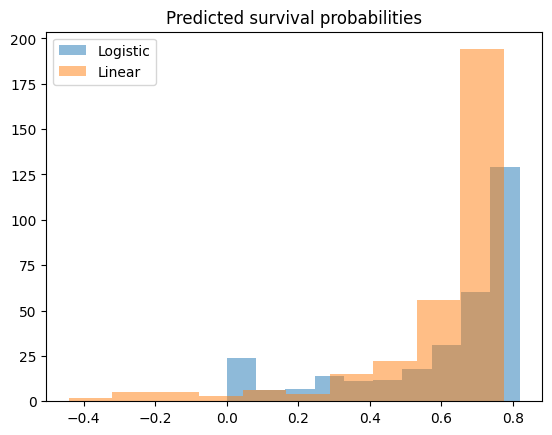

In [61]:
plt.hist(cirr["survival_prob"], alpha=0.5, label="Logistic")
plt.hist(cirr["lin_prob"], alpha=0.5, label="Linear")
plt.legend()
plt.title("Predicted survival probabilities")
plt.show()

Logistic regression is the better model. The linear regression model predicts negative probabilities, which is impossible as a probability must be between 0 and 1. Logistic regression always stays within that range and gives more reliable, interpretable predictions for a binary outcome like survival.

6.

In [62]:
X_stage = cirr.drop(columns=["Status", "Survival", "Stage"])
y_stage = cirr["Stage"]

model_stage = LogisticRegression(multi_class="multinomial", max_iter=1000)
model_stage.fit(X_stage, y_stage)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [65]:
y_pred_stage = model_stage.predict(X_stage)
print(confusion_matrix(y_stage, y_pred_stage))

[[ 0  0 15  1]
 [ 0  0 60  7]
 [ 0  0 98 22]
 [ 0  0 65 44]]


The confusion matrix shows that the model fails to identify Stage 1 and Stage 2 cases as none of these observations are correctly classified (indicated with zeros). All such cases are misclassified into higher stages, such as Stage 3 and Stage 4. There is still misclassification between these Stage 3 and Stage 4. For example, many Stage 3 cases are incorrectly predicted as Stage 4 (22 cases) and many Stage 4 cases are incorrectly predicted as Stage 3 (65 cases). The model appears skewed toward predicting later stages and does not adequately capture the structure of early stage disease.

In [68]:
probs = model_stage.predict_proba(X_stage)
print(probs[:5])

[[1.73894902e-05 4.75239153e-02 1.50374360e-01 8.02084335e-01]
 [1.00846701e-01 2.63737307e-01 3.75185762e-01 2.60230230e-01]
 [4.07843412e-02 1.84856906e-01 3.78010915e-01 3.96347837e-01]
 [3.21891914e-02 1.77339753e-01 3.75456214e-01 4.15014841e-01]
 [1.14809785e-02 2.11212315e-01 4.42795289e-01 3.34511418e-01]]


The hard classification results from .predict() do not predict every class as the model only assigns observations to Stage 3 and Stage 4 with no predictions for Stage 1 or Stage 2.

Contrastly, the .predict_proba() output provides probability estimates for all 4 classes for every observation. Although the probabilities for Stage 1 and Stage 2 are small, they are still not zero. This means that the model considers all possible stages when making predictions. Therefore, while the hard classification reduces predictions to a limited set of classes, the probability output reflects uncertainty across all stages.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

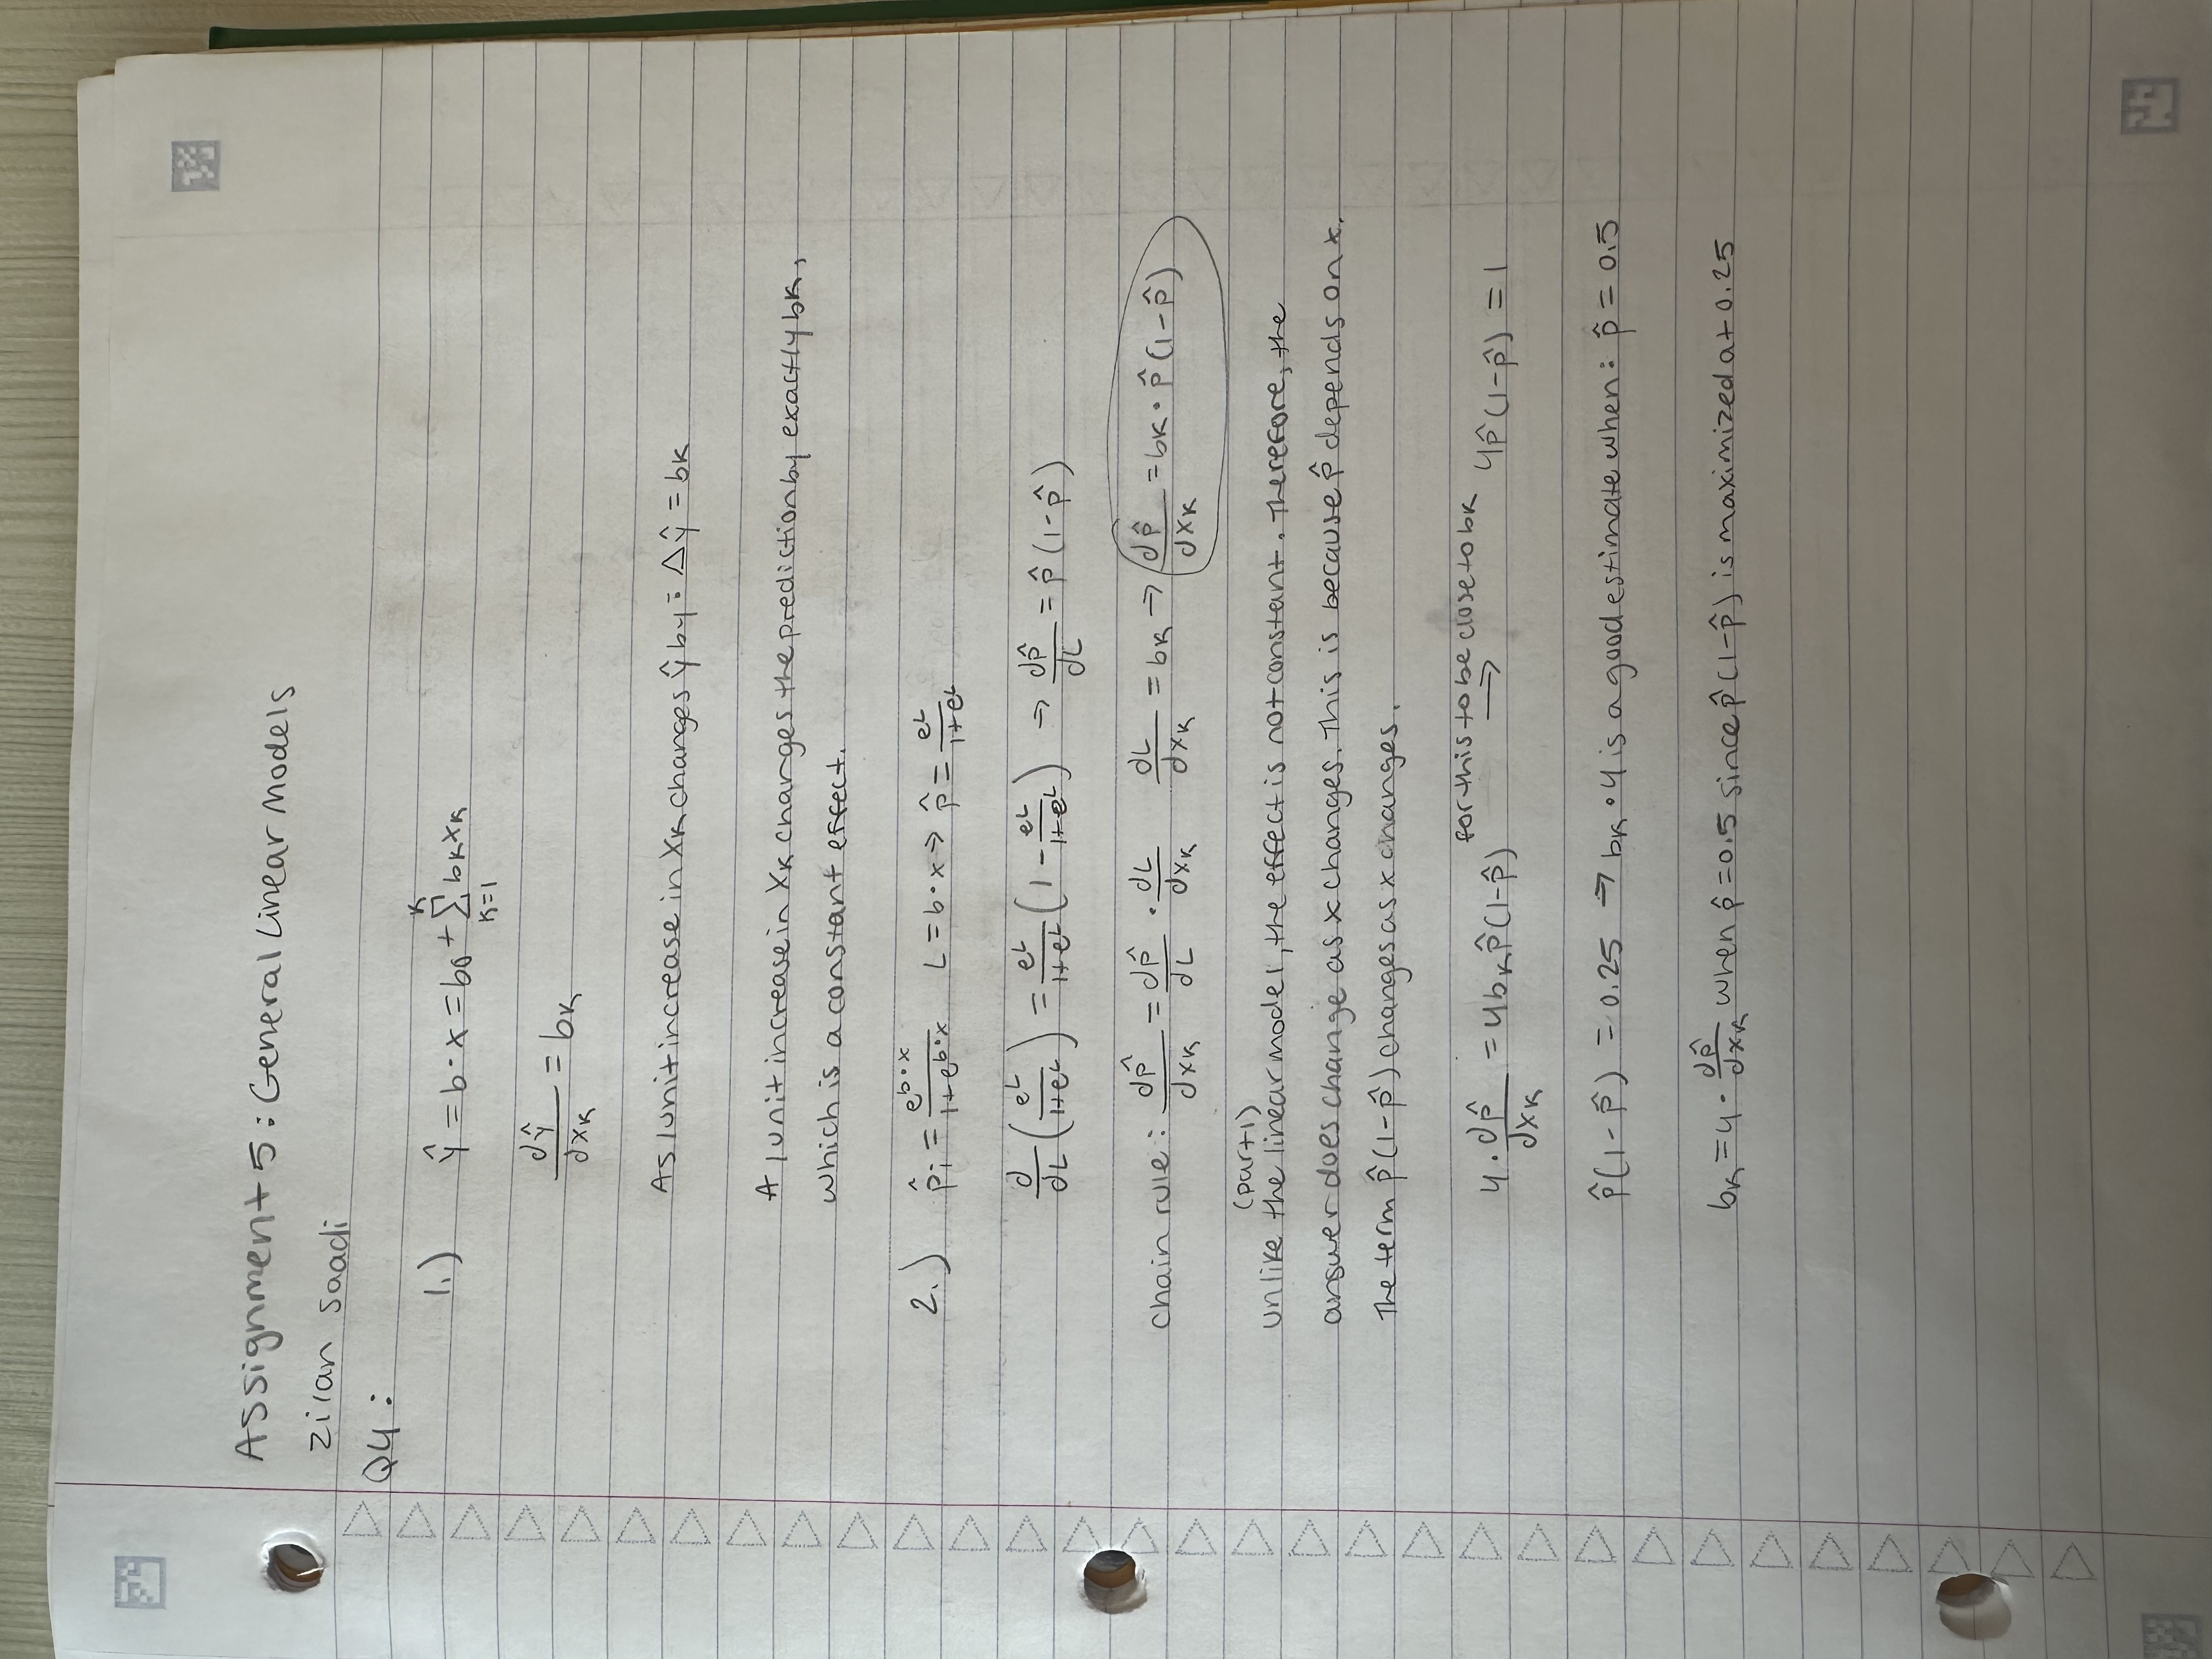

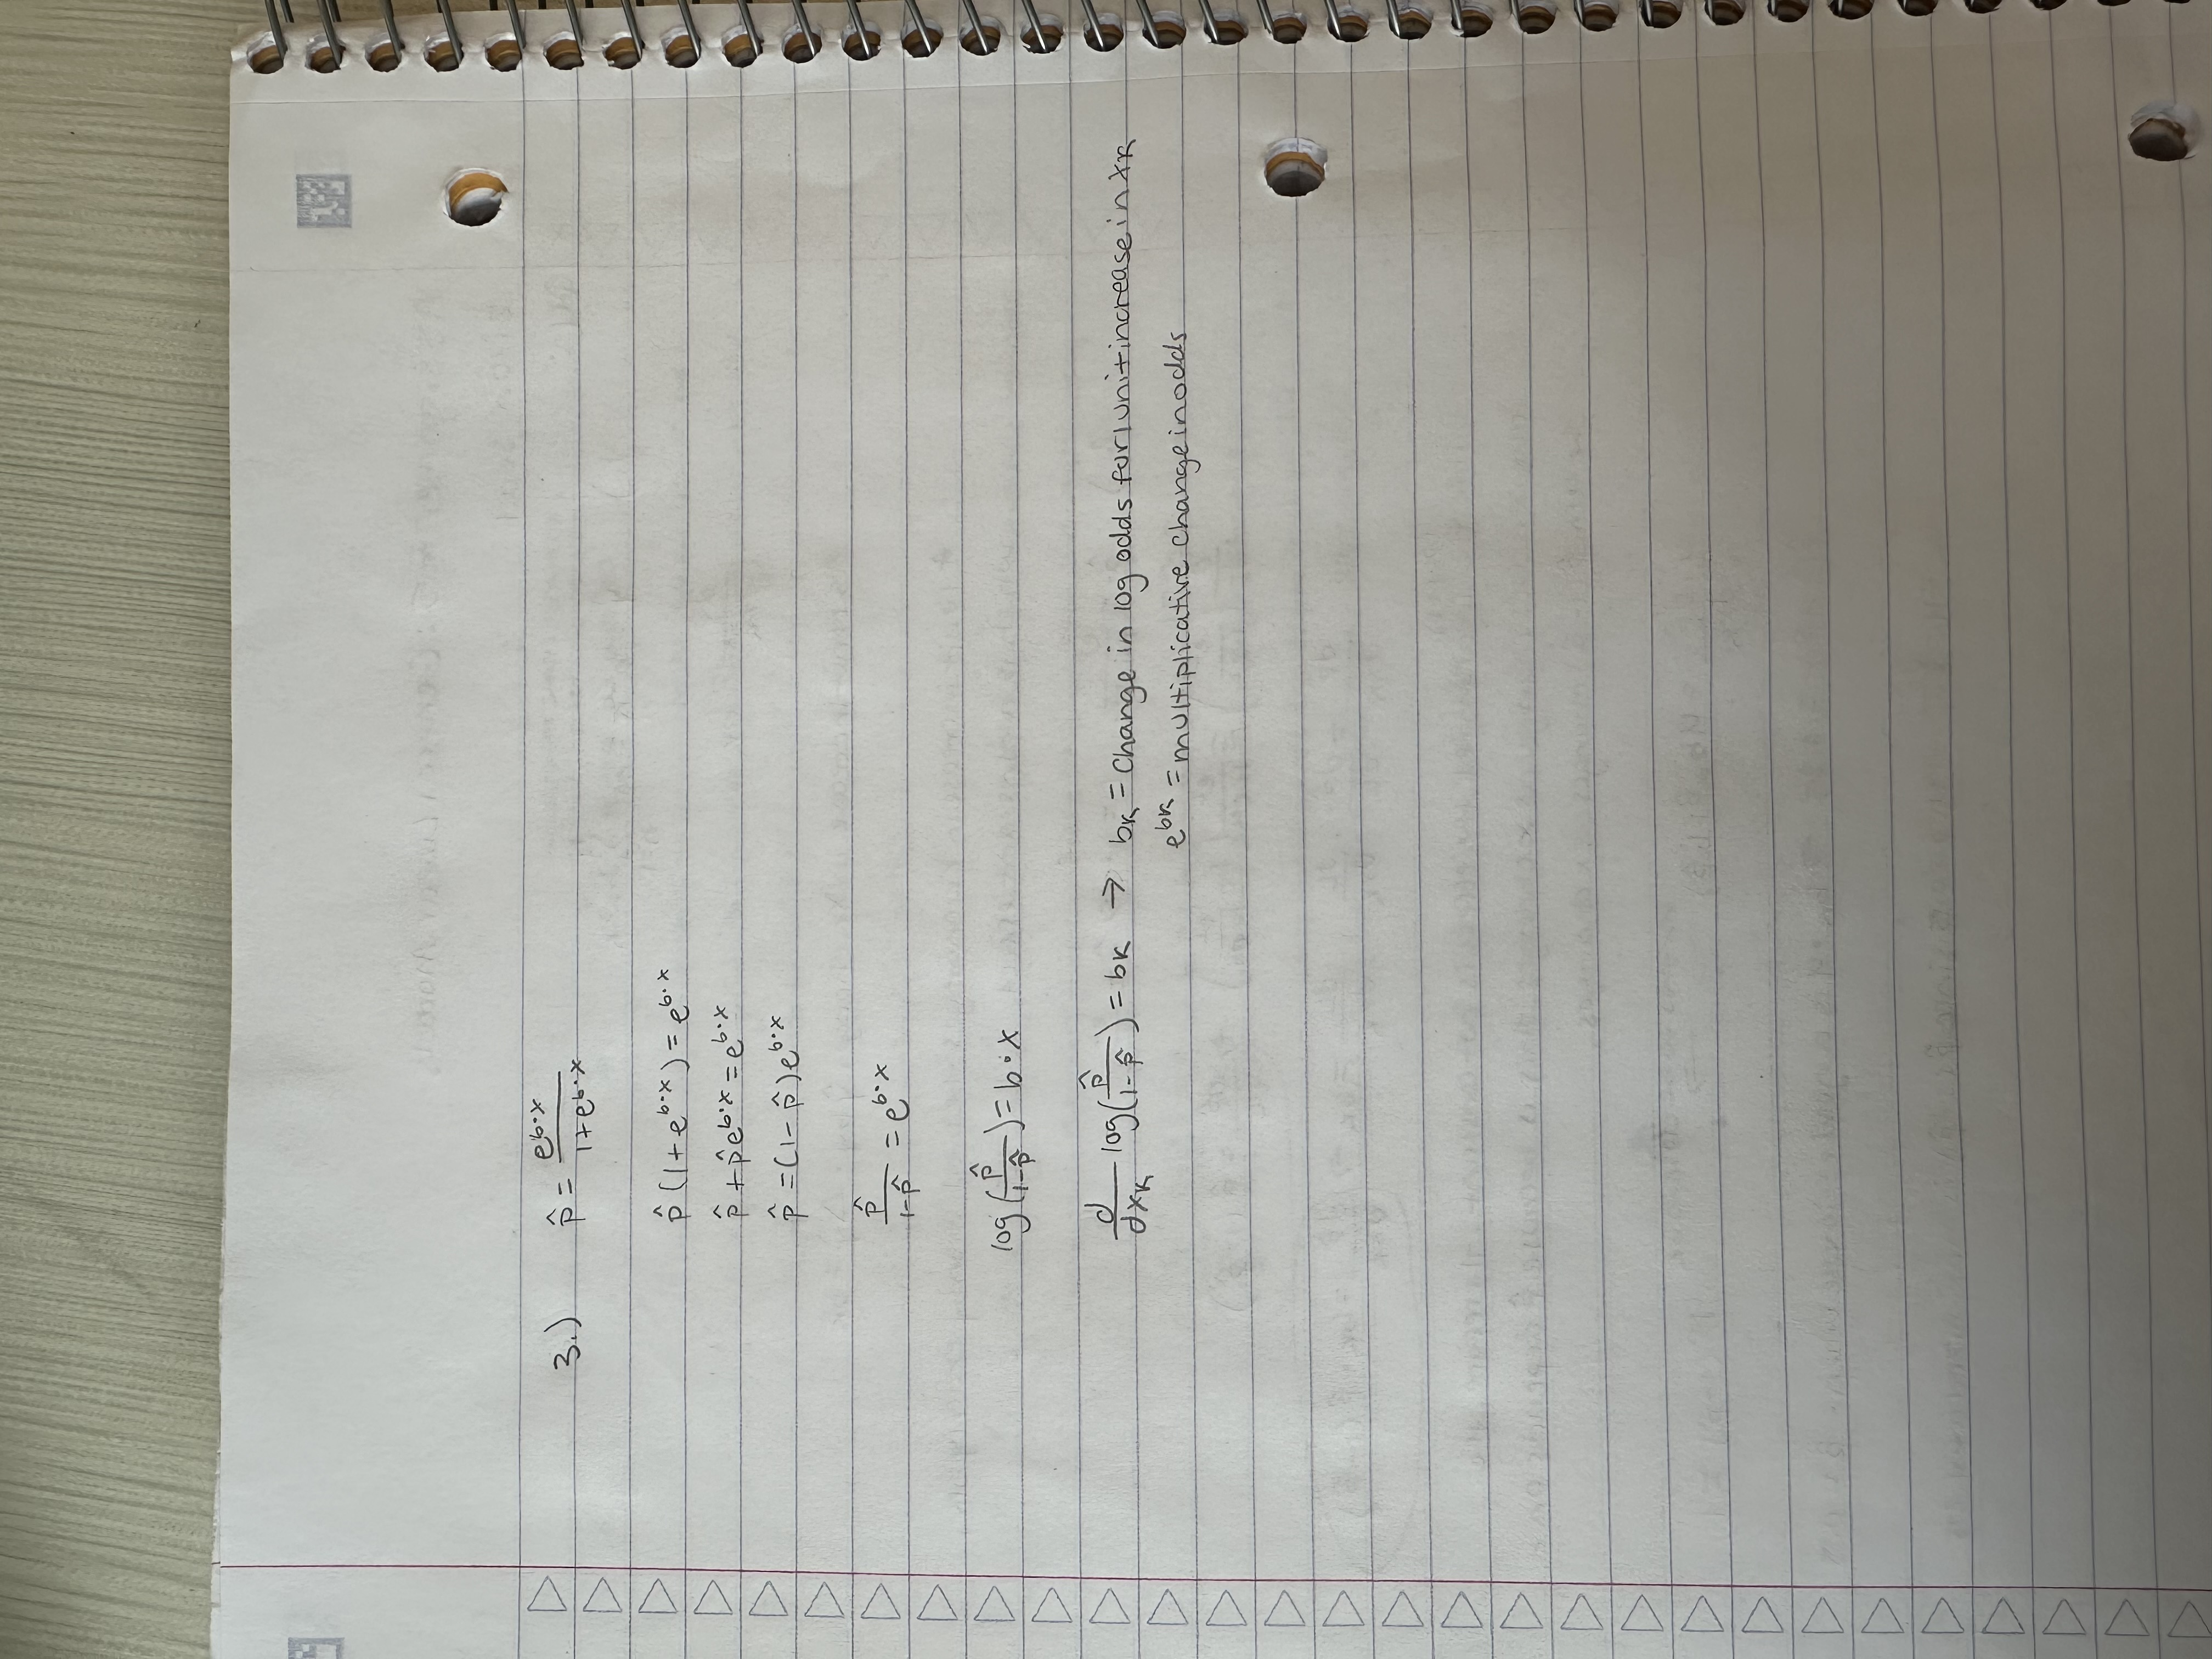